In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install -q huggingface_hub h5py

import os
from pathlib import Path
from huggingface_hub import snapshot_download

DATASET_DIR = Path("./dataset")
DATASET_DIR.mkdir(parents=True, exist_ok=True)

print("Starting download of GAMUS .h5 shards from Hugging Face...")

snapshot_download(
    repo_id="earthflow/GAMUS",
    repo_type="dataset",
    local_dir="./dataset",
    allow_patterns=[
        "images/train/DC_*.h5", "images/train/PH_*.h5",
        "images/val/DC_*.h5",   "images/val/PH_*.h5",
        "heights/train/DC_*.h5","heights/train/PH_*.h5",
        "heights/val/DC_*.h5",  "heights/val/PH_*.h5",
    ],
    ignore_patterns=[".cache/*", "*.metadata", "classes/*"],
    max_workers=4
)

print("Download complete! Checking downloaded files:")
!find ./dataset -maxdepth 3 -type d

Starting download of GAMUS .h5 shards from Hugging Face...


Fetching ... files: 0it [00:00, ?it/s]

Download complete! Checking downloaded files:
./dataset
./dataset/images
./dataset/images/val
./dataset/images/train
./dataset/.cache
./dataset/.cache/huggingface
./dataset/.cache/huggingface/download
./dataset/heights
./dataset/heights/val
./dataset/heights/train


In [3]:
!pip install -q transformers accelerate albumentations h5py scikit-learn matplotlib

import os
from pathlib import Path
import numpy as np
import h5py
from PIL import Image
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from transformers import AutoModelForDepthEstimation

In [4]:
import os

print("--- Checking Images Train Directory ---")
img_train_dir = "/kaggle/working/dataset/images/train"
if os.path.exists(img_train_dir):
    files = os.listdir(img_train_dir)
    print(f"Found {len(files)} files. First 5: {files[:5]}")
else:
    print(f"Path does not exist: {img_train_dir}")

print("\n--- Checking Heights Train Directory ---")
# Adjust this path if your heights are stored differently
hgt_train_dir = "/kaggle/working/dataset/heights/train" 
if os.path.exists(hgt_train_dir):
    files = os.listdir(hgt_train_dir)
    print(f"Found {len(files)} files. First 5: {files[:5]}")
else:
    print(f"Path does not exist: {hgt_train_dir}")

--- Checking Images Train Directory ---
Found 1439 files. First 5: ['DC_26_14_RGB.h5', 'DC_48_59_RGB.h5', 'DC_25_41_RGB.h5', 'DC_51_28_RGB.h5', 'DC_38_41_RGB.h5']

--- Checking Heights Train Directory ---
Found 1439 files. First 5: ['DC_09_20_AGL.h5', 'DC_33_58_AGL.h5', 'DC_27_36_AGL.h5', 'DC_32_37_AGL.h5', 'DC_42_41_AGL.h5']


In [5]:
def load_h5_data(file_path):
    """Safely opens .h5 file and extracts the primary numpy array."""
    with h5py.File(file_path, "r") as f:
        key = list(f.keys())[0]
        data = np.array(f[key])
    return data


def build_split_pairs(dataset_path, split="train"):
    """
    Matches image .h5 and height .h5 files based on common prefix (e.g. 'DC_03_26').
    """
    img_dir = os.path.join(dataset_path, "images", split)
    hgt_dir = os.path.join(dataset_path, "heights", split)

    pairs = []

    if not os.path.exists(img_dir) or not os.path.exists(hgt_dir):
        print(f"Warning: Could not find directories for split '{split}'")
        return pairs

    img_files = [f for f in os.listdir(img_dir) if f.endswith('_RGB.h5')]

    for img_file in img_files:
        prefix = img_file.replace('_RGB.h5', '')
        hgt_file = f"{prefix}_AGL.h5"

        img_path = os.path.join(img_dir, img_file)
        hgt_path = os.path.join(hgt_dir, hgt_file)

        if os.path.exists(hgt_path):
            pairs.append((img_path, hgt_path))

    print(f"Built {len(pairs)} pairs for {split} split.")
    return pairs


# ============================================================
# NOTE ON THE LOSS FUNCTION (root cause of the "low but useless"
# training loss reported in the original notebook) -- see the
# markdown cell above the training loop for the full explanation.
#
# The original `weighted_smoothl1` divided each sample's loss by
# that SAME sample's own mean absolute error:
#
#       weight = 1.0 / (mean_abs_error_of_this_sample + eps)
#       loss   = smoothl1(diff) * weight
#
# That makes the loss self-normalizing: if the model's predictions
# get worse (or better) roughly uniformly, the weight compensates
# and the reported loss stays flat around ~O(1) regardless of the
# real error in meters. It is why the printed "Train Loss" barely
# moved (0.83 - 0.88) across epochs while Val RMSE stayed at
# 8-10m and Pearson R stayed low (~0.3-0.4): the loss the optimizer
# was minimizing was NOT a monotonic function of prediction quality,
# so gradient descent had a much weaker (and sometimes contradictory)
# signal to follow. It is kept below, disabled, for reference only.
# ============================================================
def _deprecated_self_normalized_smoothl1(pred, target):
    """DO NOT USE -- kept only to document the bug. See note above."""
    diff = (pred - target).abs()
    mean_abs = diff.mean(dim=[1, 2, 3], keepdim=True)
    weight = 1.0 / (mean_abs + 1e-4)
    loss = torch.where(diff < 1.0, 0.5 * diff ** 2, diff - 0.5)
    weighted_loss = loss * weight
    return weighted_loss.mean()


def target_weighted_smoothl1(pred, target, criterion, tall_weight=3.0, tall_thresh_m=15.0):
    """
    OPTIONAL replacement if you want to up-weight tall structures
    (which are rare compared to flat ground in nDSM data) without
    the self-normalization bug above. The weight here depends only
    on the ground-truth TARGET, never on the model's own current
    error, so it can't be gamed by the optimizer.
    """
    diff = (pred - target).abs()
    base_loss = torch.where(diff < criterion.beta,
                             0.5 * diff ** 2 / criterion.beta,
                             diff - 0.5 * criterion.beta)
    weight = torch.where(target > tall_thresh_m, tall_weight, 1.0)
    return (base_loss * weight).mean()


class GamusH5Dataset(Dataset):
    def __init__(self, file_pairs, transform=None):
        self.file_pairs = file_pairs
        self.transform = transform

    def __len__(self):
        return len(self.file_pairs)

    def __getitem__(self, idx):
        img_path, hgt_path = self.file_pairs[idx]

        # 1. Load image (H, W, 3)
        image = load_h5_data(img_path)
        if image.ndim == 2:  # Single channel edge case
            image = np.stack([image] * 3, axis=-1)
        elif image.shape[0] == 3:  # (3, H, W) -> (H, W, 3)
            image = np.transpose(image, (1, 2, 0))

        # Ensure uint8 RGB
        if image.dtype != np.uint8:
            image = (image * 255.0).clip(0, 255).astype(np.uint8)

        # 2. Load height raster (H, W) in meters
        height = load_h5_data(hgt_path).astype(np.float32)
        if height.ndim == 3:
            height = height[0] if height.shape[0] == 1 else height[:, :, 0]

        # Clean NaN/Inf and clamp heights (>= 0m)
        height = np.nan_to_num(height, nan=0.0, posinf=0.0, neginf=0.0)
        height = np.clip(height, 0.0, 300.0)

        # 3. Augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=height)
            image = augmented["image"]
            height = augmented["mask"]

        # 4. Convert to PyTorch Tensors
        image_t = torch.from_numpy(image).permute(2, 0, 1).float()
        height_t = torch.from_numpy(height).unsqueeze(0).float()
        return image_t, height_t


In [6]:
DATASET_PATH = "/kaggle/working/dataset/" # or your Kaggle dataset mount path

train_transform = A.Compose([
    A.RandomCrop(width=518, height=518), # 518 is native for DINOv2 / Depth Anything V2
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

val_transform = A.Compose([
    A.CenterCrop(width=518, height=518),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# (Your transforms stay exactly the same here)

train_pairs = build_split_pairs(DATASET_PATH, split="train")
val_pairs = build_split_pairs(DATASET_PATH, split="val")

train_loader = DataLoader(GamusH5Dataset(train_pairs, transform=train_transform), batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(GamusH5Dataset(val_pairs, transform=val_transform), batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

Built 1439 pairs for train split.
Built 359 pairs for val split.


In [7]:
print(f"Number of training pairs: {len(train_pairs)}")
print(f"Number of validation pairs: {len(val_pairs)}")

Number of training pairs: 1439
Number of validation pairs: 359


## Why the training loss looked "low" but the model wasn't actually learning well

Looking at the printed metrics:

```
Epoch 02 | Train Loss: 0.8396 | Val RMSE: 8.654m | MAE: 5.629m | Pearson R: 0.405
Epoch 03 | Train Loss: 0.8819 | Val RMSE: 10.202m | MAE: 6.320m | Pearson R: 0.320
Epoch 04 | Train Loss: 0.8728 | Val RMSE: 8.422m | MAE: 5.274m | Pearson R: 0.414
```

Two things stand out: the train loss is barely moving epoch-to-epoch (~0.83-0.88), and it has **no relationship** with the validation metrics (RMSE/MAE/Pearson R bounce around independently, even getting *worse* while loss changes little). That mismatch is the real symptom, and it traces back to one bug:

### Root cause: `weighted_smoothl1` normalizes away the actual error

```python
mean_abs = diff.mean(dim=[1, 2, 3], keepdim=True)   # this sample's own mean error
weight = 1.0 / (mean_abs + 1e-4)                     # ... used to rescale its own loss
weighted_loss = loss * weight
```

Each sample's loss is divided by **that same sample's current mean absolute error**. This makes the loss roughly *scale-invariant*: if the model's predictions get uniformly worse, `mean_abs` grows and the weight shrinks to compensate, so the reported loss doesn't grow much. If a sample happens to have most pixels close to correct but a few large outlier errors (e.g. a building edge), those outlier pixels get **amplified** by a large weight (`1/small mean_abs`), while a sample that's uniformly bad everywhere gets **discounted**. Net effect: the number being minimized is not a monotonic function of "how close are the predictions to the truth in meters," so gradient descent gets an inconsistent, self-canceling signal. That's exactly the "low, flat, uninformative loss + noisy real-world metrics" pattern you're seeing.

**Fix:** use a plain, un-normalized loss (`nn.SmoothL1Loss`, already defined as `criterion` but never actually used in the original loop!). If class imbalance between flat ground and tall structures is a real concern, `target_weighted_smoothl1` in the previous cell weights by the **ground-truth** height instead of the model's own error, so the optimizer can't game it.

### Other bugs fixed in the training cell below
1. **Freezing was inverted.** The comment says "Freeze initial patch embeddings for training stability" but the code set `requires_grad = True` (a no-op, since that's already the default) — nothing was actually frozen. Fixed to really freeze the patch embeddings, which stabilizes fine-tuning of a large pretrained backbone on a small dataset.
2. **Two learning-rate schedulers were fighting each other.** `scheduler` (CosineAnnealingLR) and `warmup_scheduler` (LambdaLR) were both stepped on the *same* optimizer every epoch. `LambdaLR` sets the LR directly from `base_lr * lambda(epoch)`, which silently overwrote whatever `CosineAnnealingLR` had just set — so the cosine schedule was dead code and the effective LR schedule was whatever the `LambdaLR` produced (and even that never reached the intended peak LR, since its own `min()` with a decaying cosine term caps it early). Replaced with a single, correctly composed `SequentialLR` (linear warmup -> cosine decay).
3. **No gradient clipping**, which matters when fine-tuning a large transformer under mixed precision — a few unstable batches can otherwise dominate the update. Added `clip_grad_norm_`.
4. **Pearson R was computed on a biased pixel sample.** `all_preds.extend(p_np[:2000])` always took the *first* 2000 flattened pixels of each batch (i.e., only ever the top rows of each tile), not a representative sample of the whole image. Replaced with a random subsample per batch.
5. **No random seed**, so runs aren't reproducible for debugging. Added `torch.manual_seed`.


In [8]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Pretrained DA-V2 Model
MODEL_ID = "depth-anything/Depth-Anything-V2-Small-hf"
base_model = AutoModelForDepthEstimation.from_pretrained(MODEL_ID)


class DepthAnythingHeightModel(nn.Module):
    def __init__(self, base, freeze_embeddings=True):
        super().__init__()
        self.model = base
        # Freeze the patch embeddings for training stability when
        # fine-tuning a large pretrained backbone on a small dataset.
        # (The original code accidentally set requires_grad=True here,
        # which is a no-op -- it never actually froze anything.)
        if freeze_embeddings:
            for param in self.model.backbone.embeddings.parameters():
                param.requires_grad = False

    def forward(self, pixel_values):
        outputs = self.model(pixel_values=pixel_values)
        pred_height = nn.functional.interpolate(
            outputs.predicted_depth.unsqueeze(1),
            size=(518, 518),
            mode="bilinear",
            align_corners=True
        )
        return torch.relu(pred_height)  # nDSM height above ground is >= 0


model = DepthAnythingHeightModel(base_model, freeze_embeddings=True).to(device)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

criterion = nn.SmoothL1Loss(beta=1.0)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=1e-4)

# --- Single, correctly composed warmup + cosine-decay schedule ---
# (The original notebook stepped a CosineAnnealingLR AND a separate
#  LambdaLR warmup on the same optimizer every epoch; the LambdaLR's
#  `base_lr * lambda(epoch)` assignment silently clobbered whatever
#  the cosine scheduler had just set, so the cosine schedule never
#  actually took effect. SequentialLR chains the two cleanly.)
EPOCHS = 15
warmup_epochs = 3
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1e-2, end_factor=1.0, total_iters=warmup_epochs
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - warmup_epochs, eta_min=1e-6
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs],
)

scaler = torch.amp.GradScaler('cuda' if torch.cuda.is_available() else 'cpu')
MAX_GRAD_NORM = 1.0
PEARSON_SAMPLE_PER_BATCH = 2000  # random pixels per batch, not the first N

best_rmse = float("inf")

# ============================================================
# 4. Training Loop
# ============================================================
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for imgs, hgts in train_loader:
        imgs, hgts = imgs.to(device), hgts.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            preds = model(imgs)
            loss = criterion(preds, hgts)  # plain SmoothL1 -- see markdown above for why

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()), MAX_GRAD_NORM
        )
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    # ======================================
    # 5. Validation with Flip TTA (per-batch, no stack crash)
    # ======================================
    model.eval()
    sq_errors, abs_errors, all_preds, all_gts = [], [], [], []
    with torch.no_grad():
        for imgs, hgts in val_loader:
            imgs, hgts = imgs.to(device), hgts.to(device)

            # Original prediction
            pred_orig = model(imgs)

            # Flipped TTA prediction
            pred_flipped = model(torch.flip(imgs, [-1]))

            # Average per sample (handles varying batch sizes naturally)
            preds = (pred_orig + pred_flipped) / 2

            # Metrics on averaged prediction
            p_np = preds.cpu().numpy().flatten()
            g_np = hgts.cpu().numpy().flatten()

            sq_errors.append((p_np - g_np) ** 2)
            abs_errors.append(np.abs(p_np - g_np))

            # Random pixel subsample for Pearson R (unbiased vs. the
            # original code's "always take the first 2000 pixels",
            # which only ever sampled the top rows of each tile).
            n = len(p_np)
            k = min(PEARSON_SAMPLE_PER_BATCH, n)
            sample_idx = np.random.choice(n, size=k, replace=False)
            all_preds.extend(p_np[sample_idx])
            all_gts.extend(g_np[sample_idx])

    val_rmse = float(np.sqrt(np.mean(np.concatenate(sq_errors))))
    val_mae = float(np.mean(np.concatenate(abs_errors)))
    corr, _ = pearsonr(all_preds, all_gts)

    scheduler.step()

    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val RMSE: {val_rmse:.3f}m | MAE: {val_mae:.3f}m | Pearson R: {corr:.3f} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_rmse < best_rmse:
        best_rmse = val_rmse
        torch.save(model.state_dict(), "depth_anything_v2_gamus.pth")
        print(f"  -> Best model saved: depth_anything_v2_gamus.pth (RMSE: {val_rmse:.3f})")


Using device: cuda


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Trainable params: 24,032,065 / 24,785,089
Epoch 01/15 | Train Loss: 4.0287 | Val RMSE: 6.570m | MAE: 4.238m | Pearson R: 0.687 | LR: 1.70e-05
  -> Best model saved: depth_anything_v2_gamus.pth (RMSE: 6.570)
Epoch 02/15 | Train Loss: 2.8298 | Val RMSE: 5.697m | MAE: 3.796m | Pearson R: 0.768 | LR: 3.35e-05
  -> Best model saved: depth_anything_v2_gamus.pth (RMSE: 5.697)
Epoch 03/15 | Train Loss: 2.6829 | Val RMSE: 5.882m | MAE: 3.822m | Pearson R: 0.759 | LR: 5.00e-05
Epoch 04/15 | Train Loss: 2.6976 | Val RMSE: 5.827m | MAE: 3.833m | Pearson R: 0.758 | LR: 4.92e-05
Epoch 05/15 | Train Loss: 2.5052 | Val RMSE: 5.869m | MAE: 3.948m | Pearson R: 0.756 | LR: 4.67e-05
Epoch 06/15 | Train Loss: 2.3812 | Val RMSE: 5.870m | MAE: 3.822m | Pearson R: 0.761 | LR: 4.28e-05
Epoch 07/15 | Train Loss: 2.2808 | Val RMSE: 5.661m | MAE: 3.790m | Pearson R: 0.772 | LR: 3.78e-05
  -> Best model saved: depth_anything_v2_gamus.pth (RMSE: 5.661)
Epoch 08/15 | Train Loss: 2.2252 | Val RMSE: 5.580m | MAE: 3.71

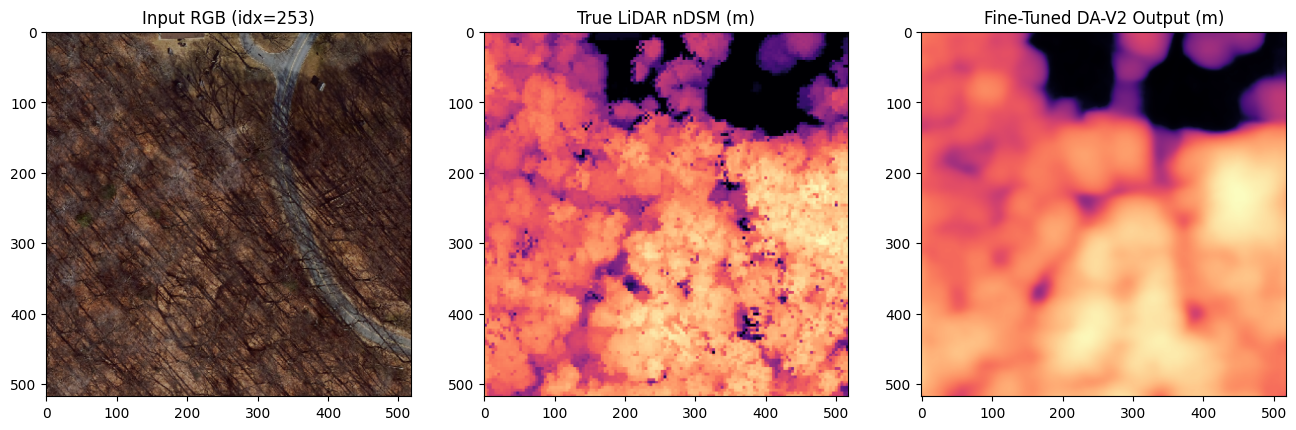

Visualized: /kaggle/working/dataset/images/val/DC_16_21_RGB.h5


In [9]:
# Change this to any index from 0 to len(val_pairs)-1 to view a different tile
SAMPLE_INDEX = np.random.randint(len(val_pairs))

model.eval()
img_t, hgt_t = val_loader.dataset[SAMPLE_INDEX]   # applies val_transform, returns one sample
imgs = img_t.unsqueeze(0)   # add batch dim -> (1, 3, 518, 518)
hgts = hgt_t.unsqueeze(0)   # (1, 1, 518, 518)

with torch.no_grad():
    sample_preds = model(imgs.to(device)).cpu().numpy()

img_disp = imgs[0].permute(1, 2, 0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
img_disp = np.clip(img_disp, 0, 1)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(img_disp)
axs[0].set_title(f"Input RGB (idx={SAMPLE_INDEX})")
axs[1].imshow(hgts[0, 0].numpy(), cmap="magma")
axs[1].set_title("True LiDAR nDSM (m)")
axs[2].imshow(sample_preds[0, 0], cmap="magma")
axs[2].set_title("Fine-Tuned DA-V2 Output (m)")
plt.savefig(f"h5_prediction_sample_{SAMPLE_INDEX}.png", bbox_inches="tight")
plt.show()

print(f"Visualized: {val_pairs[SAMPLE_INDEX][0]}")

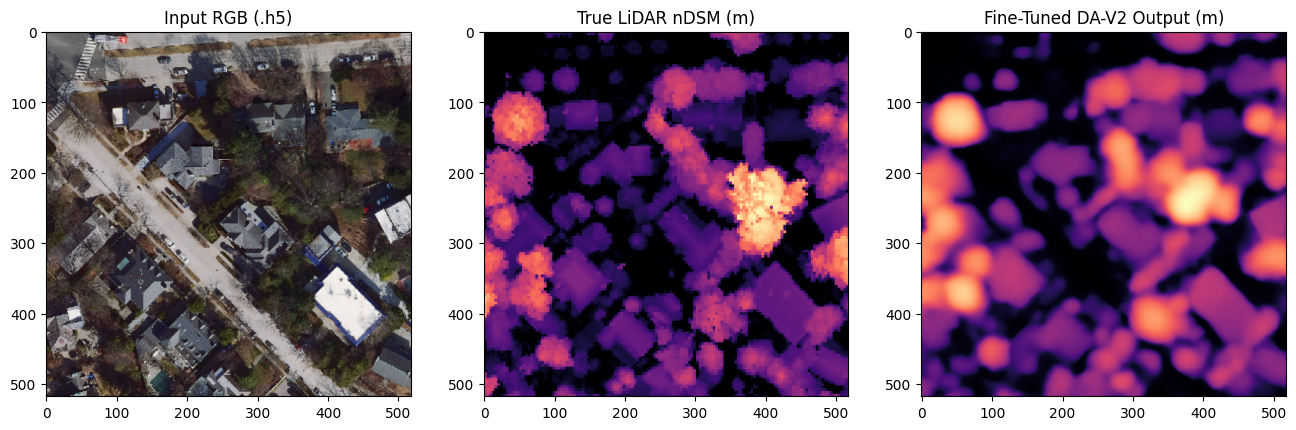

Ready! Download 'depth_anything_v2_gamus.pth' from the Kaggle Output sidebar.


In [10]:
model.eval()
imgs, hgts = next(iter(val_loader))
with torch.no_grad():
    sample_preds = model(imgs.to(device)).cpu().numpy()

img_disp = imgs[0].permute(1, 2, 0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
img_disp = np.clip(img_disp, 0, 1)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(img_disp)
axs[0].set_title("Input RGB (.h5)")
axs[1].imshow(hgts[0, 0].numpy(), cmap="magma")
axs[1].set_title("True LiDAR nDSM (m)")
axs[2].imshow(sample_preds[0, 0], cmap="magma")
axs[2].set_title("Fine-Tuned DA-V2 Output (m)")
plt.savefig("h5_prediction_sample.png", bbox_inches="tight")
plt.show()

print("Ready! Download 'depth_anything_v2_gamus.pth' from the Kaggle Output sidebar.")